一、数据初处理

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print("数据维度：", df.shape)
df.head()

df.info()

数据维度： (299, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [3]:
descriptive_stats = df.describe().T
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


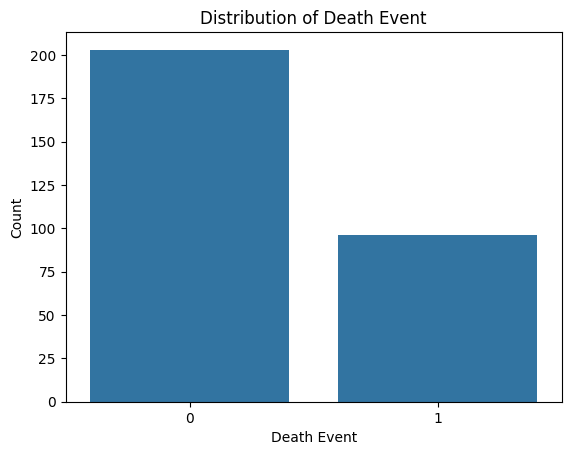

In [4]:

df["DEATH_EVENT"].value_counts()

sns.countplot(data=df, x="DEATH_EVENT")
plt.title("Distribution of Death Event")
plt.xlabel("Death Event")
plt.ylabel("Count")
plt.show()

In [5]:
missing_values = df.isnull().sum()
missing_values

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [6]:
duplicate_count = df.duplicated().sum()
print("重复行数量：", duplicate_count)


binary_cols = [
    "anaemia", 
    "diabetes", 
    "high_blood_pressure", 
    "sex", 
    "smoking", 
    "DEATH_EVENT"
]

continuous_cols = [col for col in df.columns if col not in binary_cols]

outlier_summary = []

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        "variable": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df


X = df.drop(columns=["DEATH_EVENT"])
y = df["DEATH_EVENT"]

重复行数量： 0


标准化

逻辑回归和 MLP 对特征尺度敏感，因此需要标准化。随机森林和 XGBoost 属于树模型，通常不强制要求标准化。

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682,-1.629502
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682,-1.603691
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161,-1.590785
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682,-1.590785
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682,-1.577879


阶段一数据预处理结论：

1. 数据集共有 299 名患者，13 个变量。
2. 所有变量均为数值型，不需要额外进行类别编码。
3. 每一列都是 299 non-null，说明没有缺失值。
4. 重复行数量为 0，说明没有重复记录。
5. DEATH_EVENT 分布为：未死亡人数明显多于死亡人数，存在一定类别不平衡。未死亡：67.9%
死亡：32.1%
6. 标准化已经成功完成。

异常值检查

In [8]:
binary_cols = [
    "anaemia", 
    "diabetes", 
    "high_blood_pressure", 
    "sex", 
    "smoking", 
    "DEATH_EVENT"
]

continuous_cols = [col for col in df.columns if col not in binary_cols]

outlier_summary = []

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    
    outlier_summary.append({
        "variable": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,variable,lower_bound,upper_bound,outlier_count
0,age,22.50,98.50,0
1,creatinine_phosphokinase,-581.75,1280.25,29
2,ejection_fraction,7.50,67.50,2
3,platelets,76000.00,440000.00,21
4,serum_creatinine,0.15,2.15,29
5,serum_sodium,125.00,149.00,4
6,time,-122.00,398.00,0


处理建议：保留，不删除。

原因：这些异常值大多是医学指标，不一定是错误数据，而可能代表真实的严重病情。例如：

creatinine_phosphokinase 偏高：可能提示心肌损伤或肌肉损伤
serum_creatinine 偏高：可能提示肾功能异常
ejection_fraction 极端值：可能代表严重心功能异常
serum_sodium 偏低/偏高：可能与电解质紊乱有关
platelets 极端值：可能与凝血、炎症或基础疾病有关

箱线图

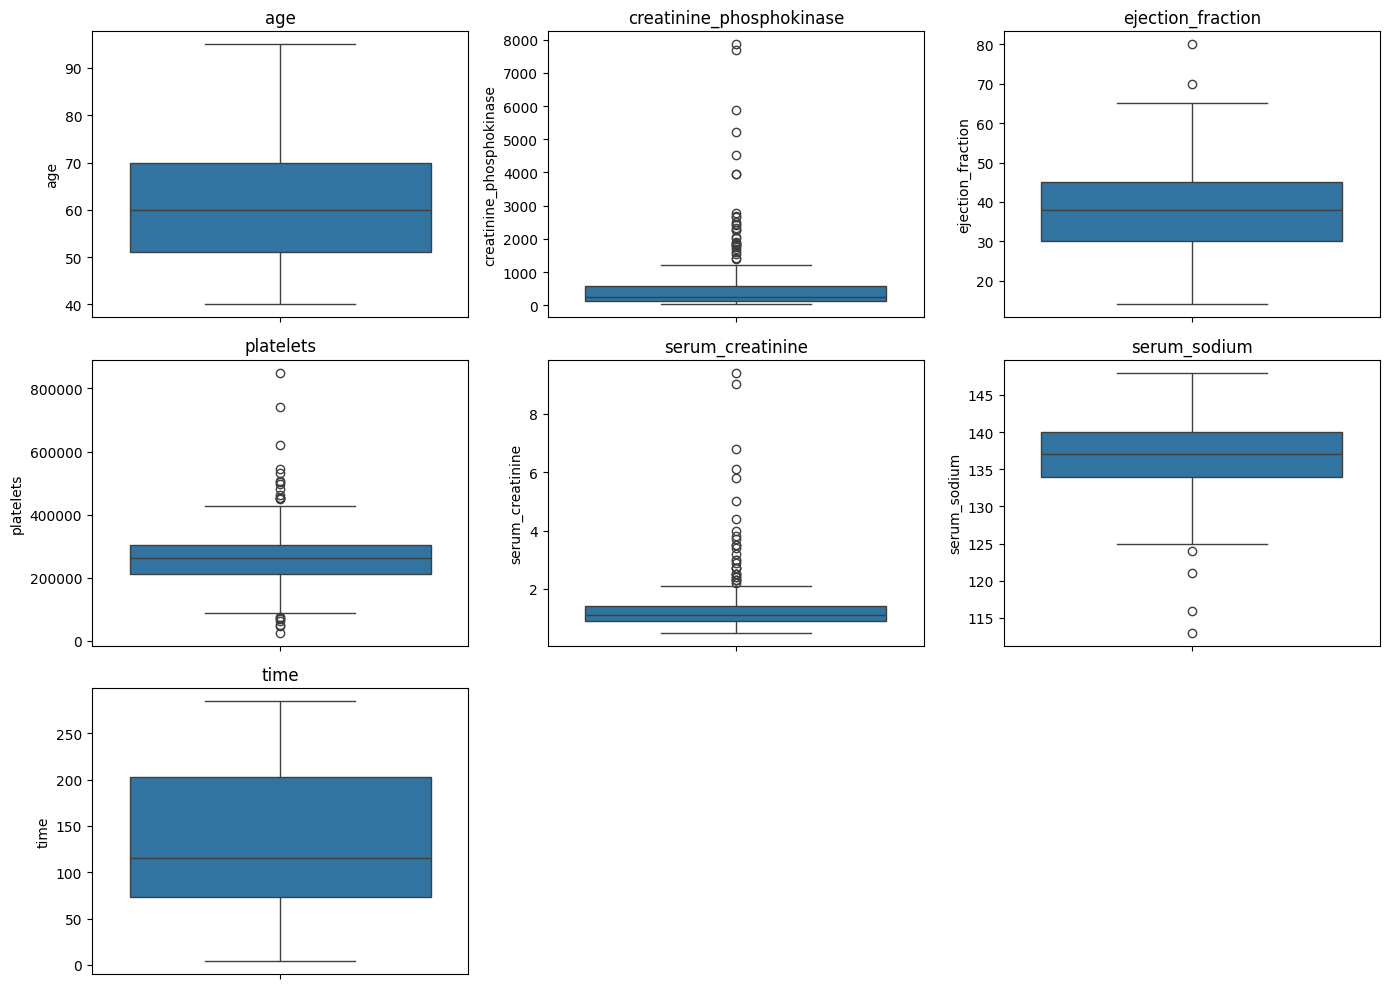

In [9]:
outlier_summary_df.to_csv("outlier_summary.csv", index=False)

plt.figure(figsize=(14, 10))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

二、因子检测

相关性热力图

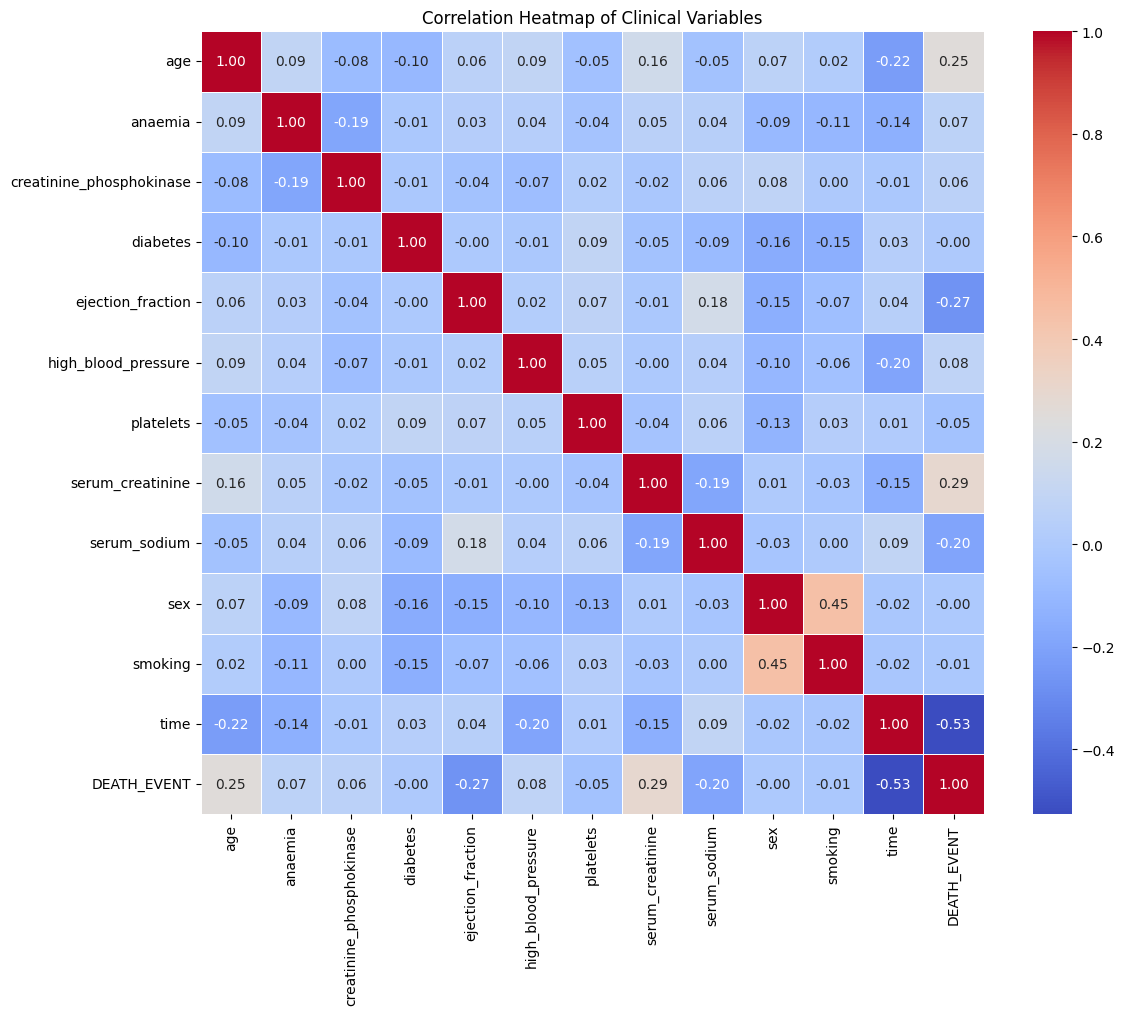

In [10]:
plt.figure(figsize=(12, 10))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Clinical Variables")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

time 与死亡事件负相关最强，说明随访时间越短，越可能观察到死亡事件。
serum_creatinine 与死亡事件正相关，血清肌酐越高，死亡风险越高。
ejection_fraction 与死亡事件负相关，射血分数越低，死亡风险越高。
age 与死亡事件正相关，年龄越大，死亡风险越高。
serum_sodium 与死亡事件负相关，血清钠越低，死亡风险越高。

单独查看各变量与死亡结局的相关性

In [11]:
death_corr = corr_matrix["DEATH_EVENT"].drop("DEATH_EVENT").sort_values(ascending=False)
death_corr

serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64

T 检验

In [12]:
from scipy.stats import ttest_ind

continuous_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

t_test_results = []

for col in continuous_cols:
    alive_group = df[df["DEATH_EVENT"] == 0][col]
    death_group = df[df["DEATH_EVENT"] == 1][col]
    
    t_stat, p_value = ttest_ind(death_group, alive_group, equal_var=False)
    
    t_test_results.append({
        "variable": col,
        "alive_mean": alive_group.mean(),
        "death_mean": death_group.mean(),
        "t_statistic": t_stat,
        "p_value": p_value
    })

t_test_df = pd.DataFrame(t_test_results)
t_test_df = t_test_df.sort_values("p_value")
t_test_df

,variable,alive_mean,death_mean,t_statistic,p_value
6,time,158.339901,70.885417,-11.006168,2.343276e-22
2,ejection_fraction,40.266010,33.468750,-4.566983,9.647153e-06
0,age,58.761906,65.215281,4.186210,4.735215e-05
4,serum_creatinine,1.184877,1.835833,4.152639,6.398962e-05
5,serum_sodium,137.216749,135.375000,-3.164501,1.872325e-03
1,creatinine_phosphokinase,540.054187,670.197917,0.901190,3.692160e-01
3,platelets,266657.489901,256381.044792,-0.844785,3.993231e-01


随机森林特征重要性

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop(columns=["DEATH_EVENT"])
y = df["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
11,time,0.357528
7,serum_creatinine,0.161895
4,ejection_fraction,0.129086
6,platelets,0.078784
2,creatinine_phosphokinase,0.075454
0,age,0.070175
8,serum_sodium,0.062774
5,high_blood_pressure,0.013339
3,diabetes,0.013307
1,anaemia,0.013138


绘制特征重要性图

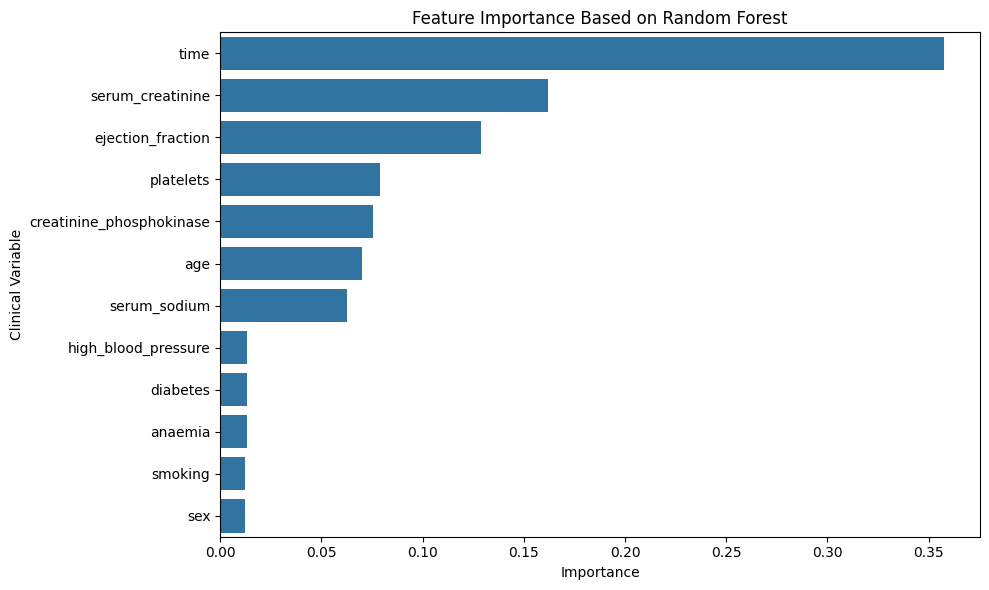

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance Based on Random Forest")
plt.xlabel("Importance")
plt.ylabel("Clinical Variable")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

输出前三危险因子

In [15]:
top3_features = feature_importance_df.head(3)
top3_features

,feature,importance
11,time,0.357528
7,serum_creatinine,0.161895
4,ejection_fraction,0.129086


## Top 3 危险因子医学解释

1. **time（随访时间）**：随访时间短的患者死亡率显著更高（死亡组均值70.9天 vs 存活组158.3天，p<0.001）。
   这反映疾病进展速度——病情越重，越早发生终点事件。注意：time存在潜在的信息泄露风险，
   在纯预测场景中需谨慎使用。

2. **serum_creatinine（血清肌酐）**：死亡组均值1.84 mg/dL，存活组1.18 mg/dL（p<0.001）。
   肌酐升高提示肾小球滤过率下降，反映心肾综合征——心衰导致肾灌注不足，
   形成恶性循环，是心衰死亡的独立预测因子。

3. **ejection_fraction（射血分数）**：死亡组均值33.5%，存活组40.3%（p<0.001）。
   EF是心脏泵血效率的核心指标，EF<40%定义为射血分数降低型心衰(HFrEF)，
   EF越低，心输出量越少，预后越差。

三、概率预测

1. 导入建模相关库

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

2. 准备特征和标签

In [17]:
X = df.drop(columns=["DEATH_EVENT"])   #X 是患者临床指标
y = df["DEATH_EVENT"]    #y 是死亡结局

3. 划分训练集和测试集

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

4. 建立四个模型

In [19]:
from xgboost import XGBClassifier
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),
    
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            max_iter=1000,
            early_stopping=True,
            random_state=42
        ))
    ])
}

5. 训练模型并评估

In [20]:
model_results = []
roc_data = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    model_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc
    })
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }

model_results_df = pd.DataFrame(model_results)
model_results_df

,model,accuracy,precision,recall,f1_score,auc
0,Logistic Regression,0.80,0.733333,0.578947,0.647059,0.854942
1,Random Forest,0.85,0.857143,0.631579,0.727273,0.897304
2,XGBoost,0.85,0.857143,0.631579,0.727273,0.848524
3,MLP,0.75,0.666667,0.421053,0.516129,0.744544


6. 绘制 ROC 曲线

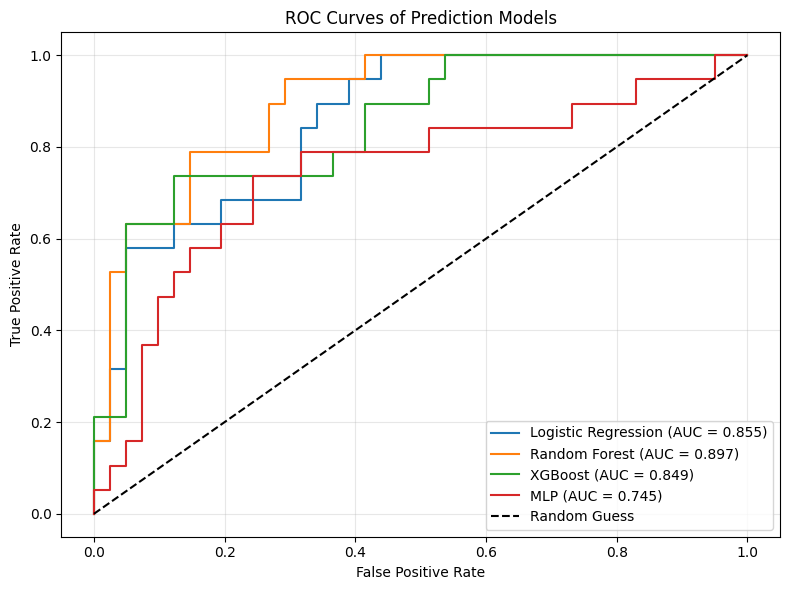

In [21]:
plt.figure(figsize=(8, 6))

for model_name, values in roc_data.items():
    plt.plot(
        values["fpr"],
        values["tpr"],
        label=f"{model_name} (AUC = {values['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Prediction Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### 模型表现总结

本实验比较了四种模型：逻辑回归、随机森林、XGBoost 和 MLP。

随机森林综合表现最佳，Accuracy 为 0.85，F1 score 为 0.727，AUC 为 0.897。

XGBoost 的 Accuracy 和 F1 score 与随机森林相同，但 AUC 更低。逻辑回归表现稳定，并且可解释性较好。MLP 表现相对较弱，可能是因为本数据集样本量较小，而表格型临床数据通常更适合树模型。

因此，本实验最终选择随机森林作为主要预测模型。

7. 保存模型结果表

In [22]:
model_results_df.to_csv("model_performance.csv", index=False)

8. 输入一个新患者，预测死亡概率

In [24]:
new_patient = pd.DataFrame([{
    'age': 65, 'anaemia': 1, 'creatinine_phosphokinase': 250,
    'diabetes': 0, 'ejection_fraction': 30, 'high_blood_pressure': 1,
    'platelets': 220000, 'serum_creatinine': 2.1, 'serum_sodium': 134,
    'sex': 1, 'smoking': 0, 'time': 90
}])

for model_name, model in models.items():
    death_probability = model.predict_proba(new_patient)[:, 1][0]
    print(f"{model_name}: predicted death probability = {death_probability:.3f}")

Logistic Regression: predicted death probability = 0.778
Random Forest: predicted death probability = 0.584
XGBoost: predicted death probability = 0.655
MLP: predicted death probability = 0.529
